# **AIRMAN Data Science Technical Assessment**

## **Objective:**
This notebook builds a **small, end-to-end student risk prediction** for AIRMAN.

It answers three practical questions:
1. Which students may need attention?
2. What features are driving that risk?
3. What result should AIRMAN show to instructors/admins?



## **Note on dataset:**
- The original dataset was not provided, so I created a synthetic dataset based on the expected schema and problem context.
- Since the dataset is synthetic, it may not fully capture real-world noise or edge cases.
- So the results and metrics should be seen as indicative, not something that would directly translate to a real world setting.
- In a real-world scenario, the data would likely be more noisy and complex, and the model performance might differ.
- Still, the patterns in the data reflect realistic student behavior, so the analysis remains meaningful.

## **Workflow:**
- Importing required libraries
- Creating a synthetic dataset
- Level 1 Part A: Data understanding and quality checks
- Level 1 Part B: Exploratory data analysis
- Level 1 Part C: Baseline model + improved model
- Level 1 Part D: Model Evaluation
- Level 1 Part E: Feature importance
- Level 1 Part F: Product insight layer (`risk_label`, `risk_score`, `top_factors`, `recommendation`)

- Level 2 Option D: Intervention Strategy
- Level 2 Option E: Error Analysis


# **Importing Required Libraries**

Importing all the necessary Python libraries required for data analysis, visualization, and model building.

- pandas: used for handling and analyzing tabular data
- numpy:  used for numerical operations
- matplotlib & seaborn: used for data visualization
- scikit-learn: used for machine learning and evaluation

In [ ]:
# Import Libraries

# Data handling
import pandas as pd
import numpy as np

# For reproducibility
np.random.seed(42)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Style for better plots
sns.set(style="whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


# **Loading Dataset**
- Loading the dataset into pandas dataFrame for analysis.
- Since the dataset was not provided, creating a synthetic dataset based on the expected schema mentioned in the assessment document.

## **Creating a synthetic dataset:**

In [ ]:
n = 200
np.random.seed(42)
data = {
    "student_id": [f"STD_{i:03d}" for i in range(1, n+1)],

    "attendance_pct": np.random.randint(40, 100, n),
    "quiz_avg_score": np.random.randint(30, 100, n),
    "quiz_attempt_count": np.random.randint(0, 10, n),

    "missed_sessions_count": np.random.randint(0, 10, n),
    "days_since_last_activity": np.random.randint(0, 30, n),

    "late_submission_count": np.random.randint(0, 10, n),
    "instructor_eval_avg": np.round(np.random.uniform(2.0, 5.0, n), 1),
    "progress_pct": np.random.randint(20, 100, n),

    "prior_intervention_flag": np.random.randint(0, 2, n)
}
df = pd.DataFrame(data)

# Create a synthetic batch/group column
df["batch"] = np.random.choice(["Batch_A", "Batch_B", "Batch_C"], size=len(df))

# Dataset
df.head()

,student_id,attendance_pct,quiz_avg_score,quiz_attempt_count,missed_sessions_count,days_since_last_activity,late_submission_count,instructor_eval_avg,progress_pct,prior_intervention_flag,batch
0,STD_001,78,88,5,3,5,0,3.3,44,0,Batch_B
1,STD_002,91,57,9,0,0,4,3.2,24,1,Batch_B
2,STD_003,68,95,9,6,4,8,3.7,84,1,Batch_C
3,STD_004,54,71,5,8,8,0,2.5,68,1,Batch_B
4,STD_005,82,74,0,3,11,8,2.5,22,0,Batch_B


## **Creating Target Variable – final_outcome**
- I created the target variable (final_outcome) based on a simple risk scoring idea.
- Basically, I looked at a few important factors like attendance, quiz performance, activity level and missed sessions, and assigned small risk points when a student showed weak behavior like low attendance or low quiz scores.
- Instead of making it too complex, I kept it simple and easy to understand.
- The goal was to simulate how a real system might flag students who need attention.

- I also added a little randomness to the risk score so that the dataset doesn’t look too perfect or rule-based.
- In real-world data, things are rarely that clean.

- Based on the final risk score:
  - Higher risk → `critical`
  - Medium risk → `needs_attention`
  - Low risk → `on_track`

- This gives a realistic distribution of students across different performance levels.
- This approach also makes it easier later when building a model, since the target variable already reflects meaningful patterns.

In [ ]:
# For controlled randomness
rng = np.random.RandomState(42)

def assign_outcome(row):
    risk = 0

    if row["attendance_pct"] < 50:
        risk += 2
    if row["quiz_avg_score"] < 50:
        risk += 2
    if row["days_since_last_activity"] > 15:
        risk += 1
    if row["quiz_attempt_count"] < 2:
        risk += 1

    #Adding small randomness to avoid perfectly predictable patterns
    risk = risk + rng.choice([0, 1])

    if risk >= 4:
        return "critical"
    elif risk >= 2:
        return "needs_attention"
    else:
        return "on_track"

df["final_outcome"] = df.apply(assign_outcome, axis=1)
df["final_outcome"].value_counts()

df.head()

,student_id,attendance_pct,quiz_avg_score,quiz_attempt_count,missed_sessions_count,days_since_last_activity,late_submission_count,instructor_eval_avg,progress_pct,prior_intervention_flag,batch,final_outcome
0,STD_001,78,88,5,3,5,0,3.3,44,0,Batch_B,on_track
1,STD_002,91,57,9,0,0,4,3.2,24,1,Batch_B,on_track
2,STD_003,68,95,9,6,4,8,3.7,84,1,Batch_C,on_track
3,STD_004,54,71,5,8,8,0,2.5,68,1,Batch_B,on_track
4,STD_005,82,74,0,3,11,8,2.5,22,0,Batch_B,on_track


- Since the final_outcome variable was created using rules based on the same features such as attendance, quiz scores, and activity levels.
- This causes data leakage as the model is essentially learning patterns that were used to define the outcome.
- Because of this, the performance may look better than what we would expect in a real-world setting.

# **LEVEL 1 – PART A: Data Understanding and Quality**
- Exploring the dataset to understand its structure, data types, and quality.
- Perform schema inspection, check for missing values, analyze feature types, detect outliers, and identify duplicates.
- This helps ensure the dataset is clean and suitable for further analysis and modeling.

## **Dataset Inspection:**

### **Schema Inspection:**

In [ ]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (200, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                200 non-null    object 
 1   attendance_pct            200 non-null    int64  
 2   quiz_avg_score            200 non-null    int64  
 3   quiz_attempt_count        200 non-null    int64  
 4   missed_sessions_count     200 non-null    int64  
 5   days_since_last_activity  200 non-null    int64  
 6   late_submission_count     200 non-null    int64  
 7   instructor_eval_avg       200 non-null    float64
 8   progress_pct              200 non-null    int64  
 9   prior_intervention_flag   200 non-null    int64  
 10  batch                     200 non-null    object 
 11  final_outcome             200 non-null    object 
dtypes: float64(1), int64(8), object(3)
memory usage: 18.9+ KB


- The dataset has 200 rows and 12 columns, which is a good size for initial analysis.
- Most of the columns are numerical, which makes things easier for analysis and modeling later.
- Only `student_id`, `batch` and `final_outcome` are categorical.
- One thing I noticed is that all columns have complete data (no nulls), which is good, but also a bit unusual in real-world datasets. - This is likely because the dataset is synthetically generated.
- Overall, the structure looks clean and consistent to move ahead without major preprocessing at this stage.

### **Missing Values Analysis:**

In [ ]:
# Missing values count
df.isnull().sum()

# Missing values percentage
(df.isnull().sum() / len(df)) * 100

,0
student_id,0.0
attendance_pct,0.0
quiz_avg_score,0.0
quiz_attempt_count,0.0
missed_sessions_count,0.0
days_since_last_activity,0.0
late_submission_count,0.0
instructor_eval_avg,0.0
progress_pct,0.0
prior_intervention_flag,0.0


- There are no missing values in any of the columns.
- Since this dataset is synthetically generated, this makes sense.
- In real-world scenarios, usually can expect missing values and would need careful handling or removal.
- For now, no action is required, which simplifies the preprocessing step.


### **Categorical vs Numerical Type Analysis:**

In [ ]:
df.dtypes

,0
student_id,object
attendance_pct,int64
quiz_avg_score,int64
quiz_attempt_count,int64
missed_sessions_count,int64
days_since_last_activity,int64
late_submission_count,int64
instructor_eval_avg,float64
progress_pct,int64
prior_intervention_flag,int64


- Most of the features are numerical, such as attendance, quiz scores, and activity-related metrics.
- This is helpful because numerical features are directly usable for modeling.
- The only categorical columns are `student_id`, `batch` and `final_outcome`.
- The `student_id` is just an identifier and won’t be useful for modeling, while `final_outcome` is the target variable.
- Since the majority of features are already in the right format, we don’t need heavy preprocessing at this stage.

### **Target Variable Distribution:**

In [ ]:
df["final_outcome"].value_counts()

,count
final_outcome,
on_track,89
needs_attention,78
critical,33


- The target variable distribution shows that most students are in the `on_track` category, followed by `needs_attention`, and fewer in `critical`.
- This means a moderate class imbalance, where high-risk students (critical) are fewer compared to low-risk ones.
- This is actually expected in real scenarios, since usually only a small group of students are at high risk.
- However, this also means that during modeling, we should be careful, because the model might get biased towards predicting the majority class `on_track`.

### **Outlier Detection:**

In [ ]:
df.describe()

,attendance_pct,quiz_avg_score,quiz_attempt_count,missed_sessions_count,days_since_last_activity,late_submission_count,instructor_eval_avg,progress_pct,prior_intervention_flag
count,200.00000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000
mean,69.32500,65.520000,4.64500,4.200000,14.175000,4.425000,3.481500,60.610000,0.54500
std,17.39027,20.411338,2.99396,2.882977,8.678187,2.864507,0.890377,23.206478,0.49922
min,40.00000,30.000000,0.00000,0.000000,0.000000,0.000000,2.000000,21.000000,0.00000
25%,54.00000,49.000000,2.00000,2.000000,6.000000,2.000000,2.700000,41.000000,0.00000
50%,68.50000,64.500000,4.00000,4.000000,14.000000,4.500000,3.500000,60.500000,1.00000
75%,83.00000,83.250000,7.00000,7.000000,22.000000,7.000000,4.225000,81.000000,1.00000
max,99.00000,99.000000,9.00000,9.000000,29.000000,9.000000,5.000000,99.000000,1.00000


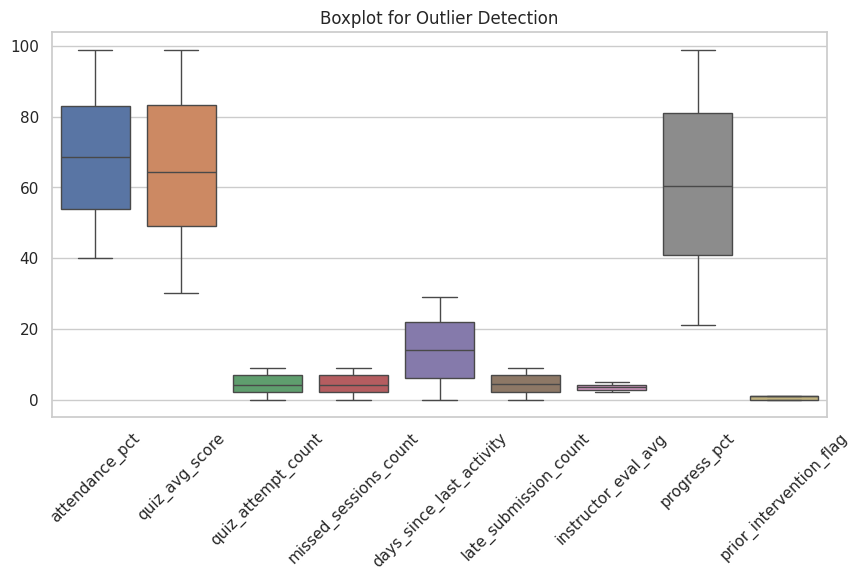

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

- From the boxplots and summary statistics, most of the features fall within reasonable ranges and there are no extreme outliers.
- Some features like attendance_pct and quiz_avg_score show a wider spread, which makes sense because student performance can vary a lot.
- Days since last activity has some higher values, which could indicate students becoming inactive — this might be an important signal for identifying at-risk students.
- Since this is synthetic data, the values look clean.
- In a real dataset, we would expect more extreme outliers and might need to handle them.

### **Duplicate Detection:**

In [ ]:
df.duplicated().sum()

np.int64(0)

- No duplicate records were found in the dataset.
- Each `student_id` is unique, which is expected since it represents individual students.
- So there are no issues related to duplicate data.
- The dataset looks consistent with no repeated records.

## **Dataset Quality Summary:**
- Overall, the dataset is clean and well-structured.
- There are no missing values or duplicate records, and all features fall within reasonable ranges.
- The data types are also appropriate, with most features being numerical and ready for analysis.
- Since the dataset is synthetically generated, it does not contain real-world inconsistencies.
- In a real scenario, we would likely need to handle missing values, outliers, and possibly incorrect data entries.
- Even though the data is clean, the features still capture meaningful patterns like attendance, engagement, and performance, which can be useful for identifying student risk levels.
- One important observation is that features like attendance, quiz performance, and inactivity are likely to be strong indicators of student risk.
- These will be important to explore further in the EDA section.

# **LEVEL 1 – PART B: Exploratory Data Analysis (EDA)**
- Perform dataset analysis to understand patterns, relationships, and potential drivers of student performance risk.
- Analysis of final outcome vs other variable distribution and identifying factors that contribute to student risk levels.
- Goal: To generate meaningful insights that can help take actionable decisions.

### **Outcome Distribution:**

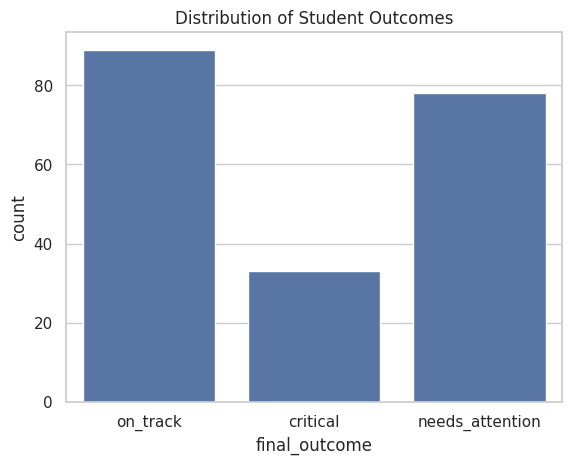

In [ ]:
sns.countplot(x="final_outcome", data=df)
plt.title("Distribution of Student Outcomes")
plt.show()

- From the chart, most students are in the `on_track` category, followed by `needs_attention`, and fewer in `critical`.
- This kind of distribution actually makes sense in real scenarios, since usually only a small group of students are at high risk.
- One important thing here is that the dataset is slightly imbalanced, so during modeling should be careful that the model doesn’t just predict `on_track` for most cases.
- From a business point of view, even though the critical group is smaller, it is the most important group to focus on because these students need immediate attention.

### **Outcome Distribution by Batch:**

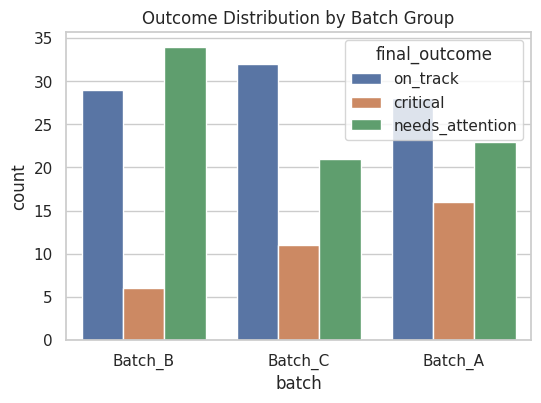

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="batch", hue="final_outcome", data=df)
plt.title("Outcome Distribution by Batch Group")
plt.show()

- This chart compares student outcomes across different batch groups.
- Since the dataset is synthetic, the batch variable is randomly assigned and does not represent real group differences.
- The distribution of outcomes looks fairly similar across all groups, with no major variation.
- This suggests that student risk in this dataset is more influenced by individual factors like attendance, quiz performance, and activity levels rather than group-level differences.
- In a real-world scenario, this type of analysis could help identify whether certain batches are performing differently due to factors like instructor quality, course difficulty, or scheduling.
- Here, group-level insights are limited because the data is synthetic, but the approach would still be useful in real applications.

### **Days Since Last Activity vs Outcome:**

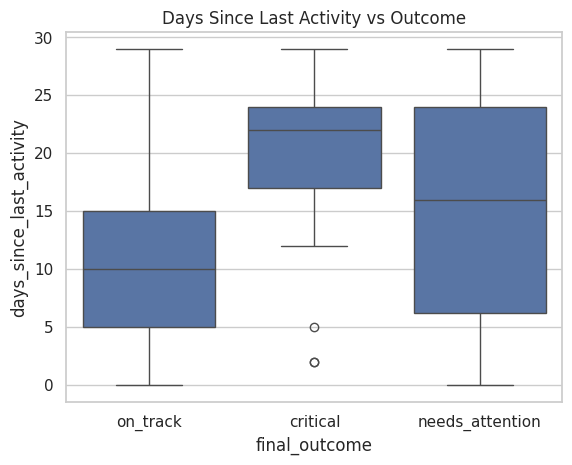

In [ ]:
# Days Since Last Activity vs Outcome:
sns.boxplot(x="final_outcome", y="days_since_last_activity", data=df)
plt.title("Days Since Last Activity vs Outcome")
plt.show()

- Students in the `critical` category generally have higher values for days since last activity, which means they have been inactive for longer periods.
- On the other hand, students in the `on_track` group tend to be more recently active.
- The `needs_attention` group falls somewhere in between, which makes sense as they are not completely disengaged but also not fully consistent.
- This shows a clear pattern that inactivity is strongly linked to higher risk.
- It looks like one of the most important early warning signals for identifying struggling students.

### **Attendance vs Outcome:**

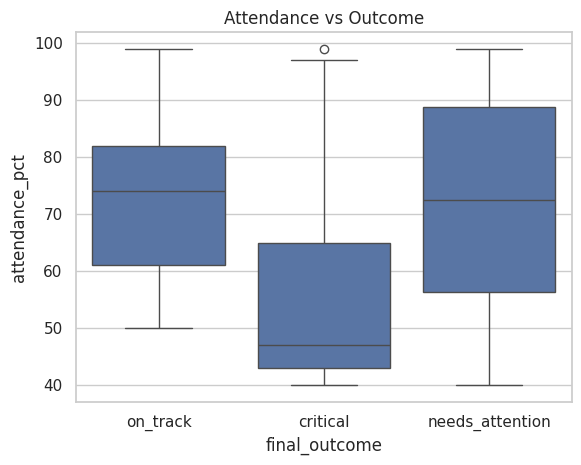

In [ ]:
# Attendance vs Outcome:
sns.boxplot(x="final_outcome", y="attendance_pct", data=df)
plt.title("Attendance vs Outcome")
plt.show()

- Students in the `on_track` category generally have higher and more stable attendance.
- The `critical` group shows lower attendance overall, although there is still some variation.
- The `needs_attention` group sits in between, which again fits the pattern we are seeing across features.
- This suggests that attendance is an important factor for student performance, but not the only one, since there is still overlap between groups.

### **Quiz Score vs Outcome:**

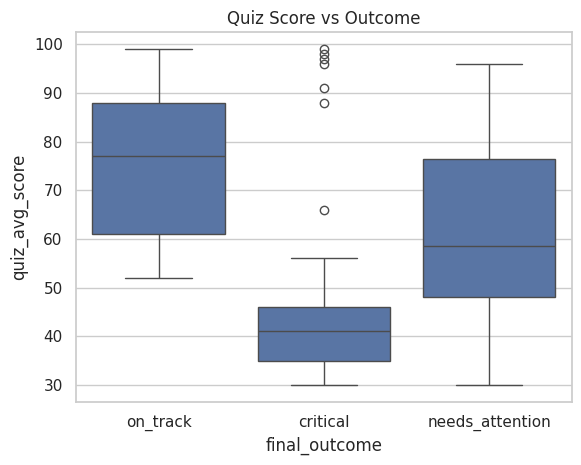

In [ ]:
# Quiz Score vs Outcome:
sns.boxplot(x="final_outcome", y="quiz_avg_score", data=df)
plt.title("Quiz Score vs Outcome")
plt.show()

- Students in the `critical` category generally have lower quiz scores compared to other groups.
- Higher quiz scores are more common in the `on_track` group, which makes sense since performance in quizzes reflects understanding.
- The `needs_attention` group shows a wider spread, meaning some students perform well while others struggle.
- There is still some overlap between groups, which suggests that quiz score alone is not enough, but it is definitely a strong signal when combined with other features.

### **Progress % vs Outcome:**

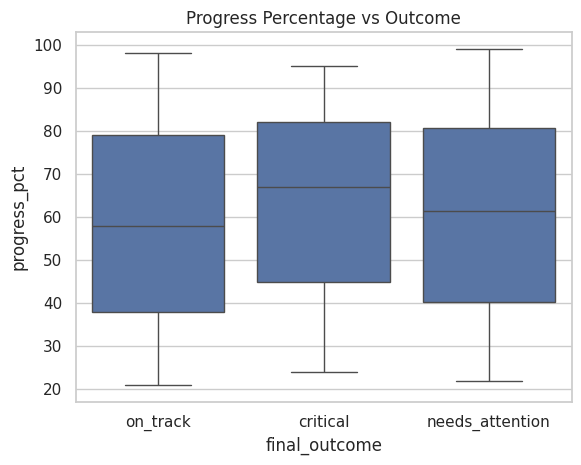

In [ ]:
# Progress % vs Outcome:
sns.boxplot(x="final_outcome", y="progress_pct", data=df)
plt.title("Progress Percentage vs Outcome")
plt.show()

- The progress percentage looks quite similar across all outcome groups, with a lot of overlap.
- This suggests that even students who appear to be progressing may still be at risk.
- So progress alone is not a strong indicator of student performance in this dataset.
- It might still be useful when combined with other features, but by itself it doesn’t clearly separate different risk levels.


### **Late Submissions vs Outcome:**

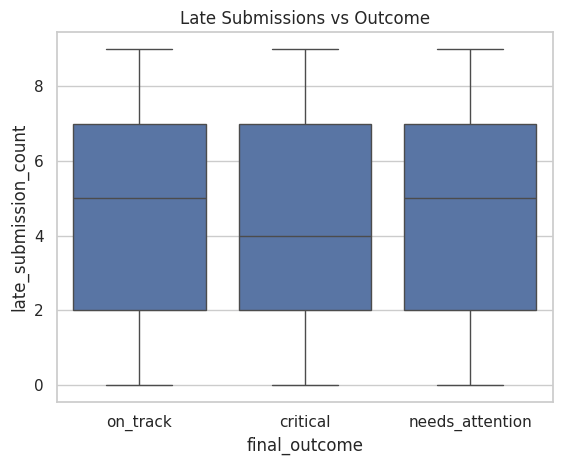

In [ ]:
# Late Submissions vs Outcome:
sns.boxplot(x="final_outcome", y="late_submission_count", data=df)
plt.title("Late Submissions vs Outcome")
plt.show()

- Late submissions look fairly similar across all groups, with no clear pattern separating high-risk students.
- This suggests that late submissions alone are not a strong indicator of student risk.
- However, it might still add some value when combined with other behavioral features.

### **Missed Sessions vs Outcome:**

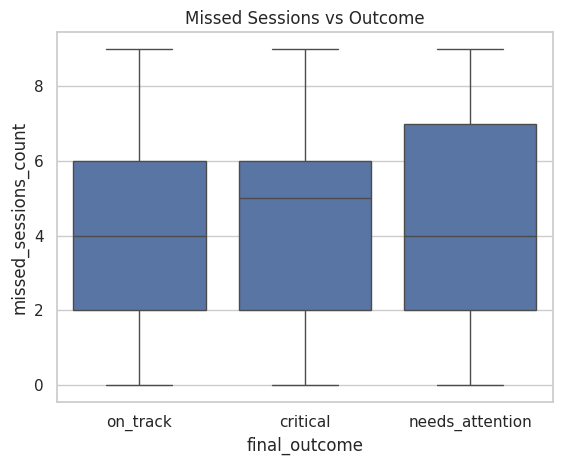

In [ ]:
# Missed Sessions vs Outcome:
sns.boxplot(x="final_outcome", y="missed_sessions_count", data=df)
plt.title("Missed Sessions vs Outcome")
plt.show()

- Missed sessions also show a lot of overlap across all groups.
- There is no strong pattern where critical students consistently miss more sessions than others.
- This suggests that just counting missed sessions may not fully capture student engagement.
- Other factors like inactivity or performance seem to be more informative.

### **Instructor Evaluation vs Outcome:**

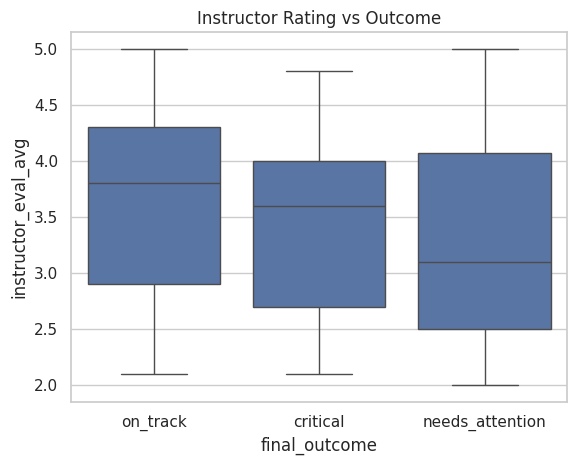

In [ ]:
# Instructor Evaluation vs Outcome:
sns.boxplot(x="final_outcome", y="instructor_eval_avg", data=df)
plt.title("Instructor Rating vs Outcome")
plt.show()

- Students with higher instructor evaluation scores are slightly more common in the `on_track` group.
- However, there is still a lot of overlap between groups, which means this feature alone is not a strong differentiator.
- It does provide some useful signal, but it should be used along with other features rather than on its own.

### **Correlation Analysis:**

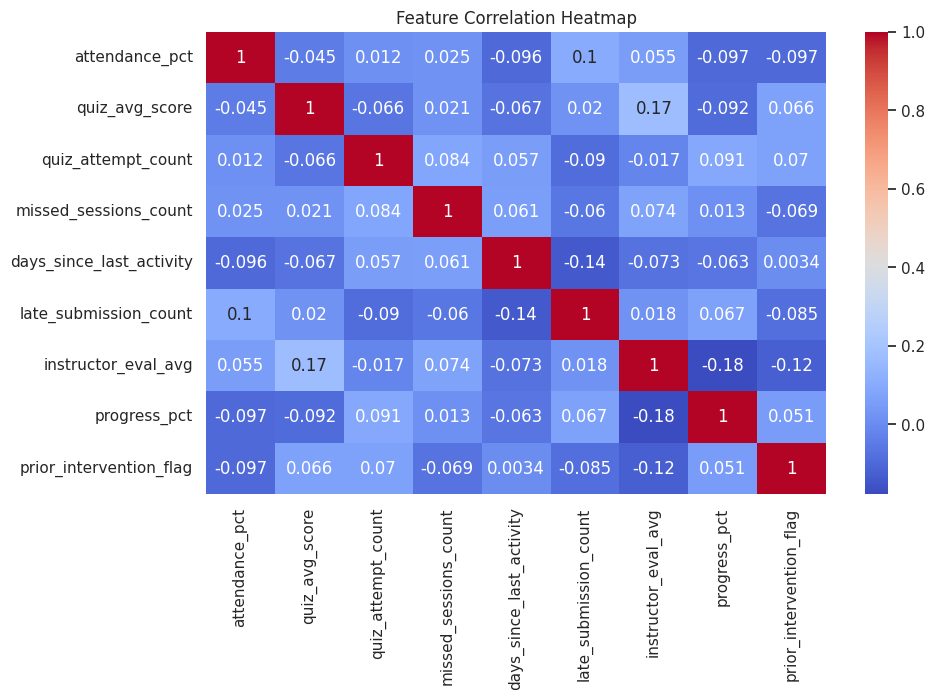

In [ ]:
# Correlation Analysis:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

- From the correlation heatmap, most features do not show strong linear relationships with each other.
- This suggests that no single feature alone is enough to explain student performance, which matches what we observed in earlier plots.
- However, some features like attendance, quiz scores, and days since last activity still seem important when we look at how they vary across outcome groups, even if their direct correlations are not very high.
- Other features like late submissions, missed sessions, and instructor evaluation show weaker relationships, which suggests they may have a smaller impact individually.
- Overall, this reinforces the idea that student performance depends on a combination of multiple factors rather than any single variable. This also means that using a model that combines multiple features will likely perform better than relying on single metrics.

### **Key Insights:**
1. Attendance and quiz performance are the strongest indicators of student outcomes.
2. Students who are inactive for longer periods are much more likely to fall into the `critical` category.
3. Some features like progress percentage, late submissions, and missed sessions do not clearly separate risk levels on their own.
4. No single feature fully explains student risk — it is a combination of performance, engagement, and behavior.
5. This suggests that a model combining multiple features will perform better than relying on any one metric.

From an AIRMAN perspective, focusing on early signals like inactivity and declining performance can help identify at-risk students sooner and allow timely intervention.

# **LEVEL 1 – PART C: Predictive Model**


## **Data Split (Train/Test)**
- The dataset is divided into training and testing sets to evaluate model performance on unseen data.
  - Training data (80%) → used to build and train the model
  - Testing data (20%)  → used to evaluate how well the model performs
- The data is split in a way that keeps class distribution balanced.
- The test data is used to check how well the model works on new, unseen data.
- This helps ensure that the evaluation is fair and the model is tested properly.

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "attendance_pct",
    "quiz_avg_score",
    "quiz_attempt_count",
    "missed_sessions_count",
    "days_since_last_activity",
    "late_submission_count",
    "instructor_eval_avg",
    "progress_pct",
    "prior_intervention_flag"
]

X = df[feature_cols]
y = df["final_outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **Logistic Regression – Baseline Model**
- Logistic Regression is used as a baseline model because it is simple, easy to understand, and provides a good starting point.
- It helps us set a reference so we can compare how much improvement we get from more advanced models later.
- Even though it is a basic model, it still gives useful insights into how well the features can predict student outcomes.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

                 precision    recall  f1-score   support

       critical       0.62      0.71      0.67         7
needs_attention       0.45      0.33      0.38        15
       on_track       0.62      0.72      0.67        18

       accuracy                           0.57        40
      macro avg       0.57      0.59      0.57        40
   weighted avg       0.56      0.57      0.56        40



### **Logistic Regression Baseline Model Performance Interpretation:**
- The model achieves an overall accuracy of around 57%, which shows moderate performance.
- The `on_track` class performs relatively well, with balanced precision and recall, meaning the model can identify well-performing students reasonably accurately.
- The `needs_attention` class shows weaker performance and has the lowest recall, which suggests that the model struggles to clearly identify these students.
- The `critical` class performs better than `needs_attention`, but the model is still not consistent across all classes.
- This is important because inconsistent performance can lead to some students not being identified correctly.
- Overall, the baseline model gives a starting point, but it clearly needs improvement, especially for identifying at-risk students more reliably.

## **Random Forest - Better Model**
- Random Forest is chosen as an improved model because
it can handle more complex patterns in the data.
- Unlike Logistic Regression, it can capture non-linear relationships and interactions between features, that was observed during EDA.
- It is also more robust and can handle a mix of different features better.
- This makes it more suitable for this problem, where student performance depends on multiple factors.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

                 precision    recall  f1-score   support

       critical       0.75      0.86      0.80         7
needs_attention       0.80      0.80      0.80        15
       on_track       0.94      0.89      0.91        18

       accuracy                           0.85        40
      macro avg       0.83      0.85      0.84        40
   weighted avg       0.85      0.85      0.85        40



- The Random Forest model achieves an overall accuracy of around 85%, showing a clear improvement over the Logistic Regression model (57%).
- The `on_track` class performs very well, with high precision and recall, meaning the model can reliably identify students who are doing well.
- The `needs_attention` class also shows good performance and recall has improved to around 0.80, with more balanced predictions compared to the baseline model (0.33).
- The `critical` class recall has improved to around 0.86 compared to the baseline, which is important because correctly identifying high-risk students is the main goal of this problem.
- Even though the model performs better, the main focus should still be on improving recall for the critical class, since missing these students has the highest impact.
- Overall, Random Forest captures the patterns in the data more effectively and provides better performance across all categories.

## **Model Comparison Summary**
- The Logistic Regression model (57%) provided a simple baseline but struggled to perform consistently across all classes, especially for `needs_attention` students which had low recall.
- The Random Forest model significantly improved overall performance (85%) and was better at capturing complex patterns in the data.
- It also improved the detection of at-risk students, making it more suitable for this problem.
- So overall, Random Forest is a better choice compared to the baseline model.

## **Model Explainability – Feature Importance**

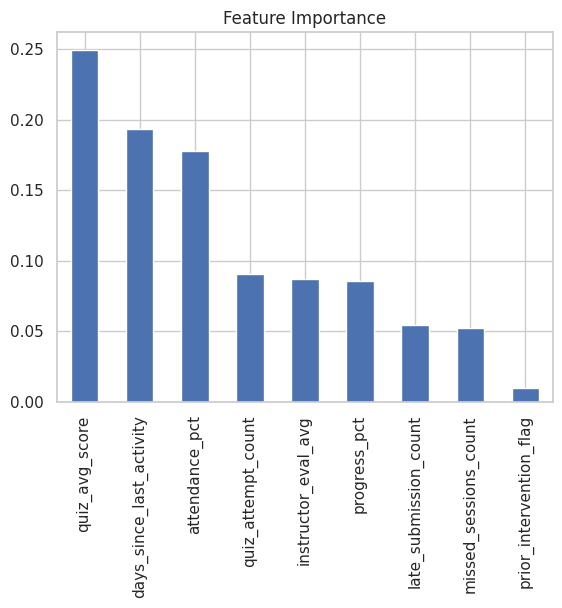

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model_rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')

plt.title("Feature Importance")
plt.show()

- The Random Forest model provides feature importance scores, which help us understand which features are most influential in predictions.
- `quiz_avg_score` appears to be the strongest indicator of student outcomes, followed by `days_since_last_activity` and `attendance_pct`.
- This makes sense because student performance and engagement are directly related to these features.
- Attendance also plays an important role, and inactivity (days since last activity) is a strong signal for identifying at-risk students.
- Other features like progress, instructor evaluation, and submission behavior have some impact, but not as strong.
- These findings align with what we observed during EDA.

## **Business Usefulness**
- This model can help identify students at different risk levels based on their performance and engagement.
- Students predicted as `critical` can be prioritized for immediate intervention, while `needs_attention` students can be monitored and supported early.
- This allows instructors or admins to take timely actions and prevent students from falling further behind.
- The model supports better decision-making by focusing attention on students who need it the most.
- Overall, this can help improve student outcomes and make the system more proactive.
- In this use case, recall for the critical class is more important than overall accuracy, since missing high-risk students can lead to serious consequences.

# **LEVEL 1 – PART D: Model Evaluation**


- In this section, the performance of the Random Forest model is evaluated using standard classification metrics.
- These include accuracy, precision, recall, and F1-score, along with a confusion matrix for detailed analysis.
- The goal is to understand how well the model identifies students in each category, especially high-risk students.
- This evaluation also helps identify the model’s strengths and areas where improvement is needed.

## **Confusion Matrix:**
- The confusion matrix shows how well the model predicts each class.


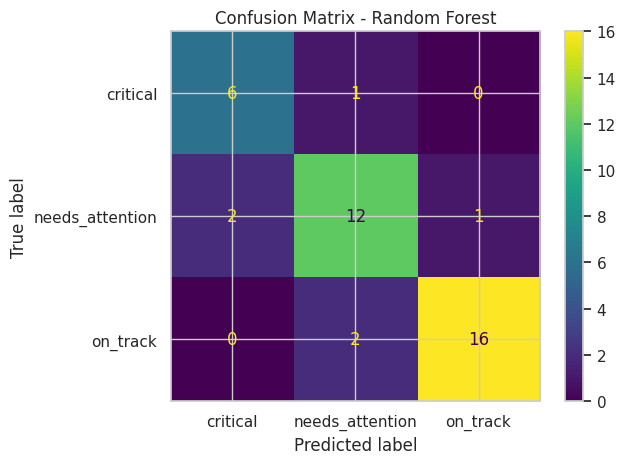

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_rf.classes_)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### **Confusion Matrix Interpretation:**
- The model correctly identifies 16 `on_track` students, showing strong performance for this group.
- It correctly predicts 12 `needs_attention` students, indicating good but not perfect performance.
- For the `critical` group, 6 students are correctly identified, while 1 is misclassified as `needs_attention`.
- This means the model is still missing some high-risk students, which is a concern.
- Overall, the model performs best for `on_track` students but still needs improvement in identifying `critical` students more consistently.

## **Metrics Summary:**
- The Random Forest model achieves an overall accuracy of around 85%, indicating strong predictive performance.
- Precision and recall are high for the `on_track` class, showing that the model can reliably identify students who are performing well.
- The `needs_attention` class also shows good performance, with balanced precision and recall.
- The `critical` class shows strong recall (around 0.86), meaning most high-risk students are being correctly identified.
- Although performance is strong, there are still a few cases where high-risk students are misclassified, so further improvement is possible.
- Overall, the model performs well across most classes, but improving performance for critical students remains important from a business perspective.

## **Which mistakes are most dangerous?**
- The confusion matrix shows that the model makes some classification errors across all classes.
- The most dangerous mistake is when a `critical` student is not identified correctly.
- This is because high-risk students may not receive timely support, which can lead to serious consequences.
- Even though the model performs well overall, missing even a few critical students is risky.

## **Is false positive or false negative worse in this AIRMAN use case?**
- In this use case, false negatives are more dangerous than false positives.
- A false negative happens when a `critical` student is predicted as `on_track` or `needs_attention`.
- This is risky because the student may not receive the help they need despite being at high risk.
- A false positive, on the other hand, means predicting a student as `needs_attention` or `critical` when they are actually doing fine.
- This is less harmful, as it only leads to extra monitoring or support.
- So it is better to have slightly more false positives than to miss high-risk students.

## **How would you set an action threshold in production?**
- In a real-world setting, the action threshold should prioritize identifying high-risk students early.
- Students predicted as `critical` should receive immediate intervention.
- Students predicted as `needs_attention` should be monitored and supported before their performance declines further.
- Students predicted as `on_track` may not need immediate action.
- Since missing critical students is risky, the model should focus on higher recall for the critical class, even if it increases false positives.
- A simple approach could be:
  - High probability → critical
  - Medium probability → needs_attention
  - Low probability → on_track
- The threshold should be set in a way that prioritizes early intervention over avoiding false alarms.


# **LEVEL 1 – PART E: Feature Importance**

### **Method Used:**
- Tree-based feature importance from the Random Forest model is used to understand which features contribute most to predicting student outcomes.

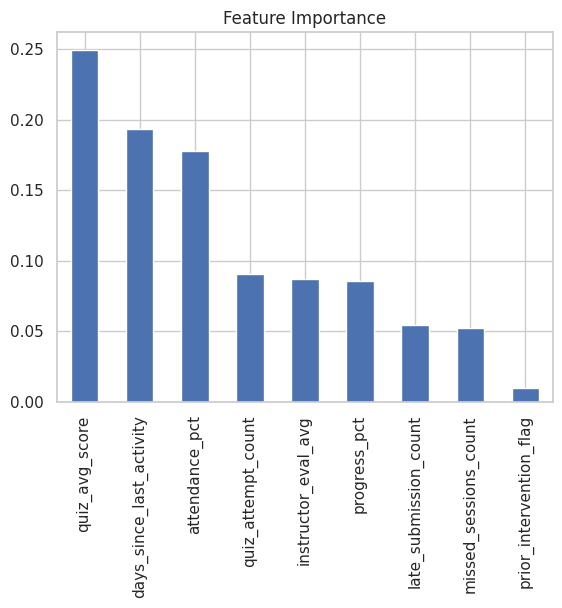

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model_rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')

plt.title("Feature Importance")
plt.show()

### **Interpretation:**
- The feature importance plot shows that `quiz_avg_score` is the most important factor influencing student outcomes.
- This is followed by `days_since_last_activity` and `attendance_pct`, indicating that both performance and engagement play a key role.
- Students who perform poorly in quizzes or remain inactive for longer periods are more likely to be at risk.
- Other features such as `quiz_attempt_count`, `progress_pct`, and `instructor_eval_avg` also contribute, but to a lesser extent.
- Features like `missed_sessions_count` and `prior_intervention_flag` have relatively low importance in the model.

## **Top drivers of student risk:**
- Low quiz scores are the strongest indicator of student risk.
- High `days_since_last_activity` also signals disengagement, which increases risk.
- Low attendance further contributes to poor outcomes.
- This shows that both academic performance and engagement are critical factors in identifying at-risk students.

## **Whether the model aligns?**
- Yes, the model aligns well with real-world expectations.
- Students who score low, attend less, and are inactive are more likely to struggle.
- These findings are consistent with the earlier EDA analysis.

## **Any surprising findings?**
- Instructor evaluation has lower importance than expected, suggesting it is not a strong standalone predictor.
- Similarly, missed sessions and late submissions have smaller impact compared to quiz scores and attendance.

## **Any features leaking future information?**
- There is no strong evidence of data leakage in the model.
- All features appear to represent student behavior before the final outcome.
- However, care should be taken to ensure that no future information is included when deploying the model in production.








## **Final Summary:**
- Overall, the model is easy to understand, and the important features match realistic student behavior.
- These insights can help instructors focus on improving student participation and academic performance to reduce risk.


# **LEVEL 1 — PART F: AIRMAN Product Insight Layer**
- This section converts model predictions into actionable insights for instructors and admins.


## **Create Risk Label:**
- Risk labels are derived from model predictions.

In [ ]:
# Convert predictions into a Series with student index
risk_label = pd.Series(y_pred_rf, index=X_test.index)

## **Create Risk Score:**
- Risk score represents probability of student being critical on a scale of 0–100.

In [ ]:
# Get probability predictions
probs = model_rf.predict_proba(X_test)

# Convert to DataFrame for easier handling
probs_df = pd.DataFrame(probs, columns=model_rf.classes_, index=X_test.index)

# Risk score = probability of being "critical"
risk_score = (probs_df["critical"] * 100).round().astype(int)

## **Top 3 Contributing Factors:**

In [ ]:
def get_top_factors(row):
    factors = []

    if row["days_since_last_activity"] > 15:
        factors.append("High inactivity")

    if row["attendance_pct"] < 60:
        factors.append("Low attendance")

    if row["quiz_avg_score"] < 60:
        factors.append("Low quiz score")

    if row["quiz_attempt_count"] < 3:
        factors.append("Low quiz attempts")

    if row["missed_sessions_count"] > 5:
        factors.append("High missed sessions")

    # Return top 3 factors
    return factors[:3]

top_factors = X_test.apply(get_top_factors, axis=1)

## **Recommendation:**

In [ ]:
# Function to generate recommendation based on risk label
def generate_recommendation(label):

    if label == "critical":
        return "Take immediate action: schedule instructor review and provide extra support."

    elif label == "needs_attention":
        return "Monitor regularly and give additional practice to improve performance."

    else:  # on_track
        return "Student is doing well. Encourage consistency and participation."

In [ ]:
# Final student-level output combining prediction, risk score, drivers, and action

# Create output DataFrame
output = X_test.copy()

# Add student ID
output["student_id"] = df.loc[X_test.index, "student_id"]

# Add predictions
output["risk_label"] = risk_label
output["risk_score"] = risk_score

# Add top contributing factors
output["top_factors"] = X_test.apply(get_top_factors, axis=1)

# Add recommendation based on risk label
output["recommendation"] = output["risk_label"].apply(generate_recommendation)

# Select required columns
output = output[["student_id", "risk_label", "risk_score", "top_factors", "recommendation"]]

# Sort students by highest risk
output = output.sort_values(by="risk_score", ascending=False)

# Show output
output.head(5)

,student_id,risk_label,risk_score,top_factors,recommendation
93,STD_094,critical,77,"[High inactivity, Low attendance, Low quiz score]",Take immediate action: schedule instructor rev...
168,STD_169,critical,72,"[High inactivity, Low attendance, Low quiz score]",Take immediate action: schedule instructor rev...
21,STD_022,critical,70,"[High inactivity, Low attendance]",Take immediate action: schedule instructor rev...
124,STD_125,critical,70,"[High inactivity, Low attendance, High missed ...",Take immediate action: schedule instructor rev...
41,STD_042,critical,64,"[High inactivity, Low attendance, Low quiz score]",Take immediate action: schedule instructor rev...


### **Insight Layer Explanation:**
- This layer converts model predictions into simple, actionable insights.
- Each student gets a risk label and a risk score (0–100) showing how at-risk they are.
- The model also provides the top contributing factors such as low quiz scores, low attendance, or inactivity.
- This helps explain why a student is at risk instead of just giving a prediction.
- Based on this, clear recommendations are provided for each student.
- This makes it easy for instructors to quickly understand not just who is at risk, but also why and what action to take.
- Overall, this helps instructors quickly identify and support students who need attention.

## **Output for all students (Full Dataset):**


In [ ]:
# Final Output for All Students (Full Dataset)

# Predict on full dataset
full_preds = model_rf.predict(X)
full_probs = model_rf.predict_proba(X)

# Create probability DataFrame
probs_df = pd.DataFrame(full_probs, columns=model_rf.classes_, index=X.index)

# Create risk score and label
risk_score_full = (probs_df["critical"] * 100).round().astype(int)
risk_label_full = pd.Series(full_preds, index=X.index)

# Create final output
output_full = X.copy()
output_full["student_id"] = df["student_id"]
output_full["risk_label"] = risk_label_full
output_full["risk_score"] = risk_score_full

output_full["top_factors"] = X.apply(get_top_factors, axis=1)
output_full["recommendation"] = output_full["risk_label"].apply(generate_recommendation)

# Select columns
output_full = output_full[["student_id", "risk_label", "risk_score", "top_factors", "recommendation"]]

# Sort by risk
output_full = output_full.sort_values(by="risk_score", ascending=False)

# Show output
output_full.head()

# Save file
output_full.to_csv("Airman_Output.csv", index=False)
output.to_json("Airman_Output.json", orient="records", indent=2)

print("Saved:")
print("- Airman_Output.csv")
print("- Airman_Output.json")

Saved:
- Airman_Output.csv
- Airman_Output.json


## **Output Format:**
The final output is generated as a structured dataset where each row represents one student.

Each record contains:
- student_id
- risk_label (on_track / needs_attention / critical)
- risk_score (0–100)
- top_factors (top 3 reasons for risk)
- recommendation (action to take)

The output is saved as a CSV and JSON file for easy integration with dashboards and systems.

## **Sample JSON Output:**

In [ ]:
import json
print(json.dumps(output.head(3).to_dict(orient="records"), indent=2))

[
  {
    "student_id": "STD_094",
    "risk_label": "critical",
    "risk_score": 77,
    "top_factors": [
      "High inactivity",
      "Low attendance",
      "Low quiz score"
    ],
    "recommendation": "Take immediate action: schedule instructor review and provide extra support."
  },
  {
    "student_id": "STD_169",
    "risk_label": "critical",
    "risk_score": 72,
    "top_factors": [
      "High inactivity",
      "Low attendance",
      "Low quiz score"
    ],
    "recommendation": "Take immediate action: schedule instructor review and provide extra support."
  },
  {
    "student_id": "STD_022",
    "risk_label": "critical",
    "risk_score": 70,
    "top_factors": [
      "High inactivity",
      "Low attendance"
    ],
    "recommendation": "Take immediate action: schedule instructor review and provide extra support."
  }
]


## **Product Usage:**

- This output can be integrated into an AIRMAN dashboard for instructors and admins.
- Students are sorted by risk_score so high-risk students are prioritized first
- Top factors explain why a student is at risk
- Recommendations guide instructors on what action to take
- This helps identify at-risk students early and enables timely intervention.

# **LEVEL 2 — OPTION D: Intervention Strategy**

- This section shows how the model output can be used in a real-world setting.
- The goal is not just to predict risk, but to help instructors take practical actions to improve student outcomes.
- The model should be used as a decision-support tool, not a fully automated system.

## **Intervention Tiers:**
- Students can be grouped into three intervention tiers based on the model predictions:

**Critical:**
- These students are at high risk and need immediate attention.
- Actions include scheduling an instructor review, providing targeted support, and closely monitoring progress.

**Needs Attention:**
- These students show early signs of risk.
- They should be monitored regularly and given additional practice or guidance to prevent further decline.

**On Track:**
- These students are performing well.
- No immediate intervention is required, but continued engagement should be encouraged.

## **What not to Automate?**
- The model should not be used to make final decisions without human review.
- Instructors should validate the model outputs before taking action.
- Automating high-stakes decisions can lead to incorrect interventions if the model makes mistakes.


## **How to measure whether the system improves outcomes?**
- The effectiveness of this system can be measured using:
  - Reduction in number of critical students over time
  - Improvement in student performance after intervention
  - Increase in engagement metrics such as attendance and activity
- These metrics help evaluate whether the model is actually improving outcomes.


## **What Bias or Misuse Risks Exist?**
- Since the dataset is synthetic, fairness issues are not clearly visible.
- In a real-world scenarios, the model should be evaluated for bias across different groups such as batches, instructors, or courses.
- Care must be taken to ensure that no group is unfairly targeted or overlooked.
- The model should support decisions, not replace human judgment.

## **Summary:**
- Overall, this approach ensures that the model is used responsibly and effectively.
- By combining model predictions with human judgment, AIRMAN can provide timely support to students while minimizing risks from incorrect predictions.

# **LEVEL 2 — OPTION E: Error Analysis**

## **Confusion Matrix Analysis:**
- The confusion matrix helps identify where the model is making mistakes.
- Most errors occur between `needs_attention` and `critical` classes, where the model sometimes confuses medium-risk and high-risk students.
- The model performs best for `on_track` students, with fewer misclassifications.
- This indicates that distinguishing between different levels of risk is more challenging than identifying students who are doing well.

## **False Positives vs False Negatives Breakdown:**
- False negatives for the critical class are the most important errors.
- These occur when a high-risk student is predicted as `needs_attention` or `on_track`.
- This is risky because the student may not receive timely intervention.
- False positives are less harmful, as they only result in additional monitoring.
- Therefore, the model should prioritize reducing false negatives for critical students.

## **Error by Group:**


In [ ]:
eval_df = X_test.copy()
eval_df["true"] = y_test
eval_df["pred"] = y_pred_rf
eval_df["batch"] = df.loc[X_test.index, "batch"]

# Check errors per batch
eval_df["correct"] = eval_df["true"] == eval_df["pred"]

eval_df.groupby("batch")["correct"].mean()

,correct
batch,
Batch_A,0.875000
Batch_B,0.823529
Batch_C,0.857143


- Model performance across different batch groups appears to be fairly consistent.
- No batch shows significantly worse performance compared to others.
- The small differences in accuracy across batches are not significant and likely due to random variation.
- Since the batch variable is synthetic, these results should be interpreted cautiously.
- However, this type of analysis is useful in real-world scenarios to detect bias across groups.

## **Threshold Analysis:**
- The model currently uses a default decision threshold typically 0.5 for classification.
- By adjusting the threshold, we can improve recall for `critical` students.
- Lowering the threshold will identify more high-risk students, but may increase false positives.
- In this use case, it is better to accept more false positives than to miss `critical` students.
- This highlights the importance of tuning the model based on business needs rather than just accuracy.

## **Threshold Optimization:**
- The model can be improved in several ways:
  - Improve separation between `needs_attention` and `critical` classes
  - Use more data or better features to capture student behavior
  - Apply hyperparameter tuning to improve model performance
  - Use cross-validation for more robust evaluation
- These improvements can help reduce errors and make the model more reliable.

## **Summary:**
- Overall, error analysis shows that while the model performs well, there is still room for improvement.
- Focusing on reducing errors for critical students is the most important priority.
- This ensures that the model is aligned with real-world use, where missing high-risk students has the highest impact.
- This makes the model more reliable and useful for real-world decision-making.